In [74]:
from operator import index

# from sympy import *
from sympy import symbols, Piecewise, integrate, var, solve, Eq, diff

from sympy.interactive import init_printing

init_printing(pretty_print=True, use_latex="mathjax")
x, y = var("x y", real=True)
import matplotlib.pyplot as plt
import pandas as pd
from anastruct.fem.system import *

Ra, Rb, Fr_y = symbols('Ra Rb Fr_y', real=True)

# geometria da viga
b = 30 * 10 ** -2  # m (largura da secção)
h = 100 * 10 ** -2  # m (altura da secção)
I_inertia_moment = b * h ** 3 / 12
A_area = b * h
c = 2  # m (comprimento da secção para análise)

# propriedades do concreto
E = 200 * 10 ** 9  # Pa (módulo de elasticidade)
G = 80 * 10 ** 9  # Pa (módulo de elasticidade transversal)
rho = 2000  # kg/m³ (massa específica do material)
v = 0.3  # (coeficiente de Poisson)

# forças aplicadas
F1 = -4 * 10 ** 3  # N (força aplicada no ponto 1)
F2 = F1
F3 = -12 * 10 ** 3  # N (força aplicada no ponto 3)

# comprimentos dos vãos para carga pontual
b2 = 1.5  # m (comprimento do vão 2)

# carga distribuída móvel
q_movel = -2 * 10 ** 3  # N/m (carga distribuída)

# carga distribuída de peso próprio
g = 9.81  # m/s² (aceleração da gravidade)
q_peso = -A_area * rho * g  # kg (massa da secção)

# comprimentos dos vãos
L_spam1 = 8 * c  # m
L_spam2 = 2 * c  # m

# coordenadas dos pontos de análise
coord = [[i * 2, 0] for i in range(0, 13)]
nomes = [f'S{i}' for i in range(1, 12)]
pontos_analises = {nome: ponto for nome, ponto in zip(nomes, coord)}
nodes = [
    (0, 0), (2, 0), (4, 0), (6, 0), (7.5, 0), (8, 0), (9, 0),
    (10, 0), (12, 0), (14, 0), (16, 0), (18, 0), (20, 0)
]
df1 = pd.DataFrame(nodes, columns=['x', 'y'], index=range(1, 14))
df1.index.name = "Ponto"
df1['Nome'] = [
    'S1', 'S2', 'S3', 'S4 + F1', 'F2', 'S5', 'F3', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11'
]
df1 = df1[['Nome', 'x', 'y']]
df1
# pontos_analises

,Nome,x,y
Ponto,,,
1,S1,0.0,0
2,S2,2.0,0
3,S3,4.0,0
4,S4 + F1,6.0,0
5,F2,7.5,0
6,S5,8.0,0
7,F3,9.0,0
8,S6,10.0,0
9,S7,12.0,0


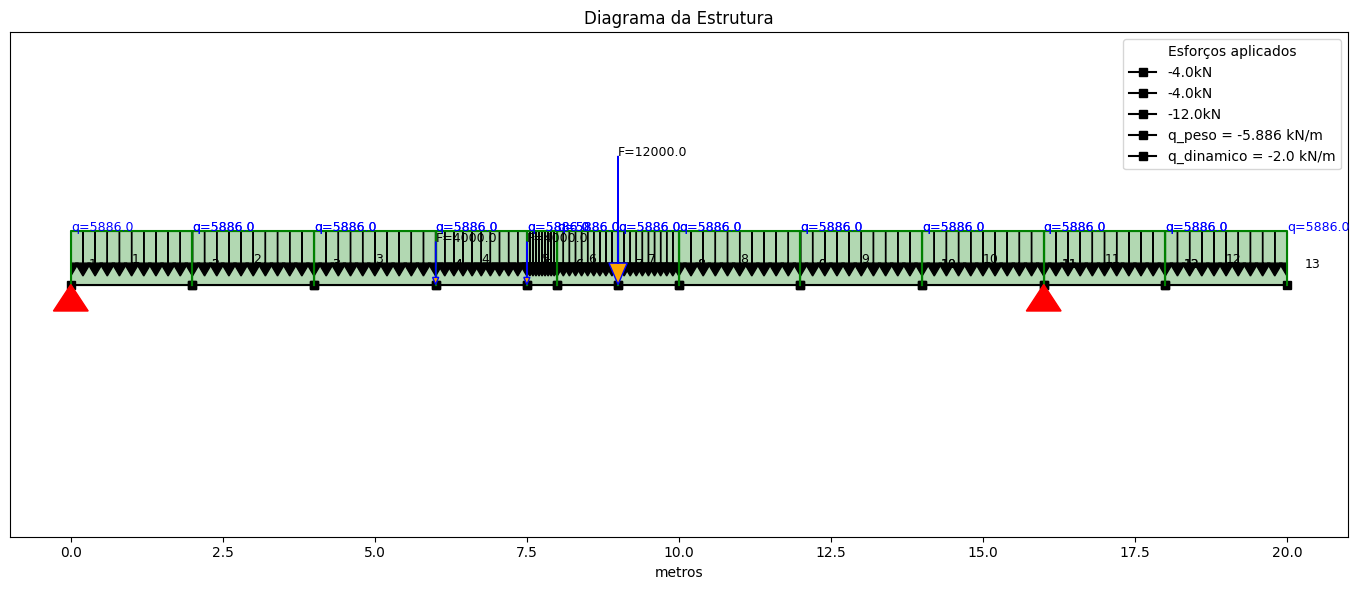

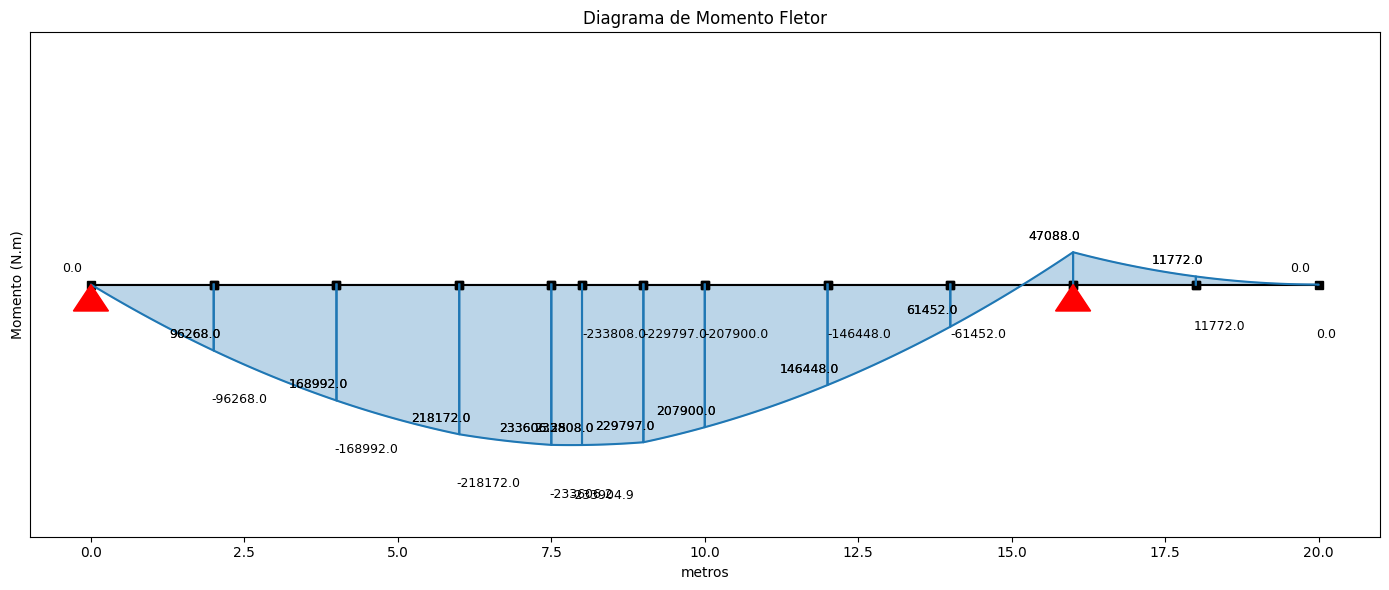

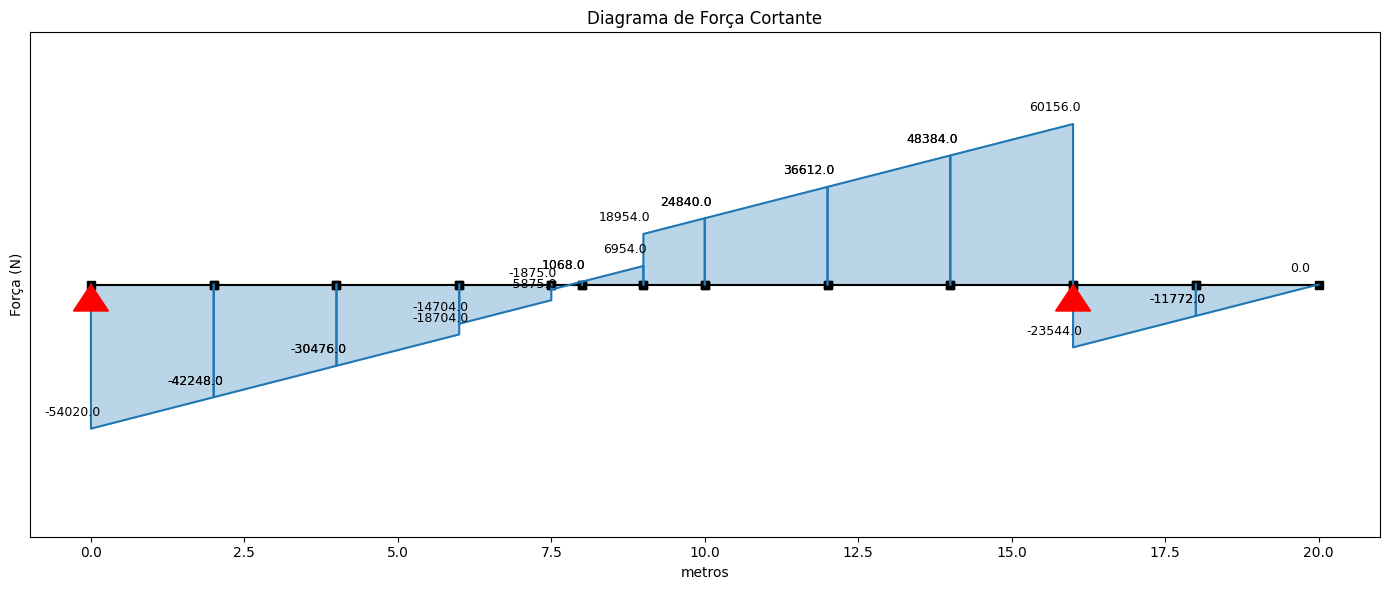

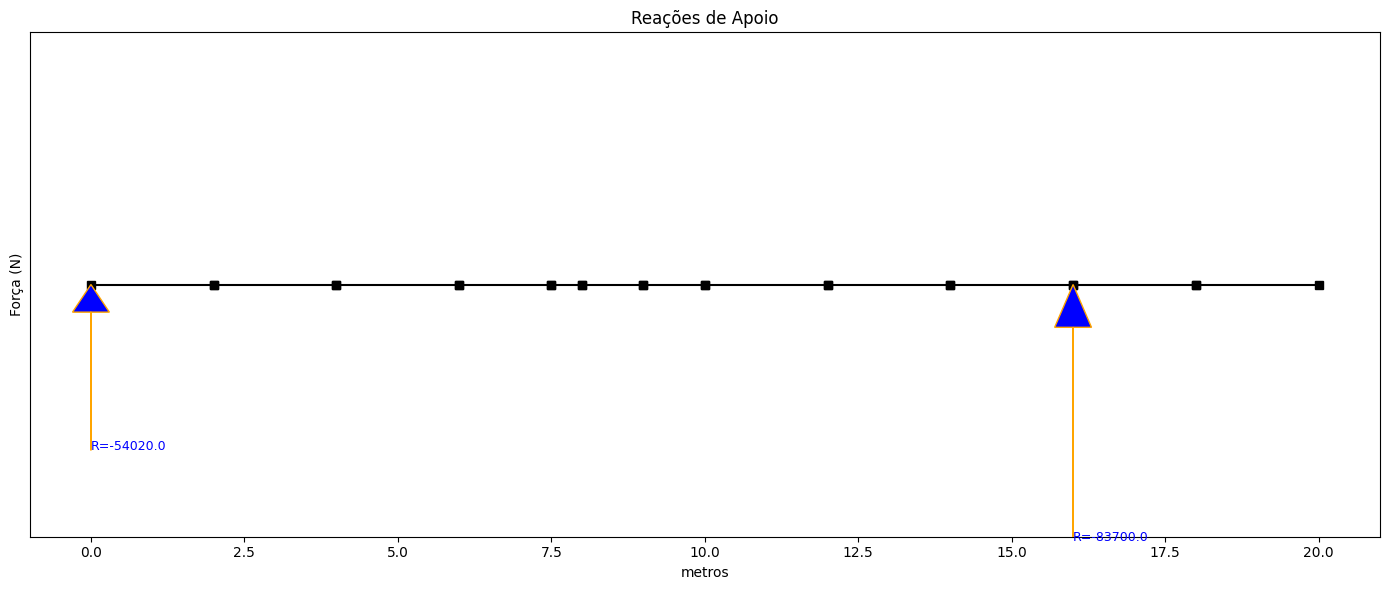

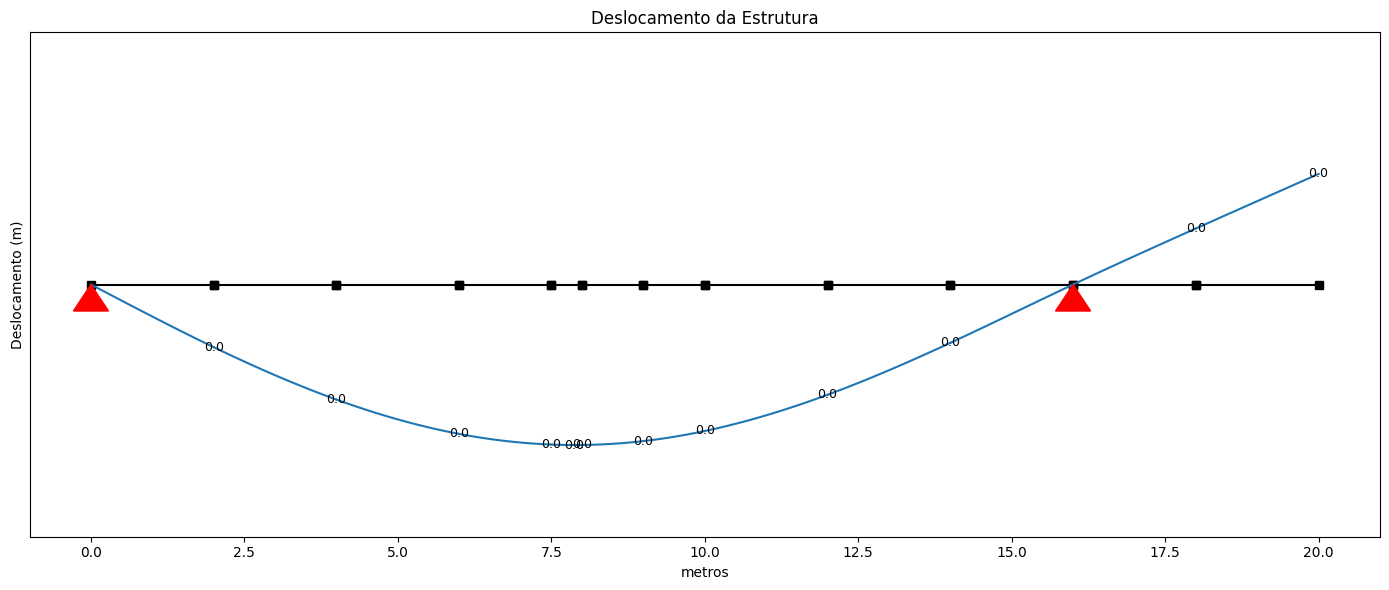

,id,Força Horizontal (N),Força Vertical (N),Torque (N.m),Deslocamento Horizontal (m),Deslocamento Vertical (m),Deflexão (rad)
Ponto,,,,,,,
S1,1,-0.0,-54020.0,-0.0,-0.0,0.000000,0.000006
S2,2,0.0,0.0,0.0,0.0,0.000011,0.000005
S3,3,0.0,-0.0,-0.0,0.0,0.000020,0.000004
S4 + F1,4,-0.0,-0.0,-0.0,0.0,0.000026,0.000002
F2,5,0.0,-0.0,-0.0,0.0,0.000028,0.000000
S5,6,-0.0,-0.0,-0.0,0.0,0.000028,-0.000000
F3,7,0.0,0.0,-0.0,0.0,0.000028,-0.000001
S6,8,-0.0,-0.0,0.0,0.0,0.000026,-0.000002
S7,9,0.0,-0.0,0.0,0.0,0.000019,-0.000004


In [75]:
def apoios2(l_span1, l_span2, q1_fixo, q2_movel, f1, f2, f3, lf, ea):
    ss = SystemElements(load_factor=lf, EA=ea, EI=ea)  # Criação do sistema
    # Lista de coordenadas da viga (x, y)

    # Adicionar elementos à viga
    for i in range(len(nodes) - 1):
        ss.add_element(location=[nodes[i], nodes[i + 1]])

    # Adição dos apoios fixos
    ss.add_support_hinged(node_id=1)  # Suporte 1
    ss.add_support_hinged(node_id=11)  # Suporte 2

    # Adição da carga distribuída dinâmica
    ss.q_load(element_id=[3, 4, 5, 6, 7], q=q2_movel, direction='y')  # Carga distribuída móvel entre 6 e 10 m

    # Adição da carga distribuída de peso próprio
    ss.q_load(element_id=range(1, 13), q=q1_fixo, direction='y')

    # Adição dos nós de carga pontual
    ss.point_load(node_id=[4, 5, 7], Fy=[f1, f2, f3])

    ss.solve(force_linear=True)

    ss.show_structure(figsize=(14, 6), scale=.55, show=False)
    plt.xlabel("metros")
    plt.title("Diagrama da Estrutura")
    plt.tight_layout()
    plt.yticks([])
    plt.legend([f'{f1 / 1000}kN', f'{f2 / 1000}kN', f'{f3 / 1000}kN', f'q_peso = {q1_fixo / 1000} kN/m',
                f'q_dinamico = {q2_movel / 1000} kN/m'], title="Esforços aplicados", loc='upper right',
               bbox_to_anchor=(1, 1))
    plt.savefig("images/diagrama.png")
    plt.show()

    ss.show_bending_moment(figsize=(14, 6), show=False, scale=0.55)
    plt.xlabel("metros")
    plt.ylabel("Momento (N.m)")
    plt.yticks([])
    plt.title("Diagrama de Momento Fletor")
    plt.tight_layout()
    plt.savefig("images/momento.png")
    plt.show()

    ss.show_shear_force(figsize=(14, 6), show=False, scale=0.55)
    plt.xlabel("metros")
    plt.ylabel("Força (N)")
    plt.yticks([])
    plt.title("Diagrama de Força Cortante")
    plt.tight_layout()
    plt.savefig("images/cortante.png")
    plt.show()

    # Reações de apoio
    ss.show_reaction_force(figsize=(14, 6), show=False, scale=0.55)
    plt.xlabel("metros")
    plt.ylabel("Força (N)")
    plt.yticks([])
    plt.title("Reações de Apoio")
    plt.tight_layout()
    plt.savefig("images/reacoes.png")
    plt.show()

    ss.show_displacement(figsize=(14, 6), show=False, scale=0.55)
    plt.xlabel("metros")
    plt.ylabel("Deslocamento (m)")
    plt.yticks([])
    plt.title("Deslocamento da Estrutura")
    plt.tight_layout()
    plt.savefig("images/deslocamento.png")
    plt.show()

    data = []
    for i in range(1, 14):
        data.append(ss.get_node_results_system(node_id=i))

    df = pd.DataFrame(data, columns=data[0].keys())
    df.index = ['S1', 'S2', 'S3', 'S4 + F1', 'F2', 'S5', 'F3', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']
    df.index.name = "Ponto"
    df = df.round(6)
    df.rename(columns={'Fy': 'Força Vertical (N)',
                       'Fx': 'Força Horizontal (N)',
                       'Tz': 'Torque (N.m)',
                       'ux': 'Deslocamento Horizontal (m)',
                       'Vy': 'Força Cortante (N)',
                       'uy': 'Deslocamento Vertical (m)',
                       'phi_z': 'Deflexão (rad)',
                       }
              , inplace=True)
    df.to_excel(excel_writer="out/resultados.xlsx", sheet_name="Resultados", index=True, header=True, engine='openpyxl')

    # for i in range(1, 14):
    #     data.append(ss.get_element_results_system(element_id=i))
    #
    # df2 = pd.DataFrame(data, columns=data[0].keys())
    # df2.index = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12']
    # df2.index.name = "Elemento"
    # df2 = df2.round(6)
    # df2.rename(columns={'Fy': 'Força Vertical (N)',
    #                    'Fx': 'Força Horizontal (N)',
    #                    'Tz': 'Torque (N.m)',
    #                    'ux': 'Deslocamento Horizontal (m)',
    #                    'Vy': 'Força Cortante (N)',
    #                    'uy': 'Deslocamento Vertical (m)',
    #                    'phi_z': 'Deflexão (rad)',
    #                    }
    #           , inplace=True)
    # df2.to_excel(excel_writer="out/resultados.xlsx", sheet_name="Elementos", index=True, header=True, engine='openpyxl')
    # df2.to_latex(buf="out/elementos.tex", index=True, header=True, longtable=True, caption="Resultados dos Elementos", label="tab:elementos", bold_rows=True)


    return df


db = apoios2(L_spam1, L_spam2, q_peso, q_movel, F1, F2, F3, 1, 210000000000)
db


In [76]:
# Definição das funções de Macaulay


Eq1 = Eq(0, Ra + Rb + q_peso * (L_spam1 + L_spam2) + q_movel * (2 * c) + F1 + F2 + F3)  # equilíbrio de forças
print(Eq1.simplify())
print(q_peso, q_movel, F1, F2, F3)

# análise dos momentos a partir de Ra
Eq2 = Eq(q_peso / 2 * (20) ** 2 + q_movel / 2 * (10 ** 2 - 6 ** 2) + F1 * 6 + F2 * 7.5 + F3 * 9 + Rb * 16,
         0)  # equilíbrio de momentos
print(Eq2.simplify())
apoios = solve([Eq1, Eq2], (Ra, Rb))
print(apoios.keys())
Ra = apoios[Ra]
Rb = apoios[Rb]

# Definição da função de momento fletor M(x) utilizando Piecewise do Sympy
M = Piecewise(
    (Ra * x + q_peso / 2 * x ** 2,                                                                                                                              (0 <= x) & (x < 2)),
    (Ra * x + q_peso / 2 * x ** 2,                                                                                                                              (2 <= x) & (x < 6)),
    (Ra * x + q_peso / 2 * x ** 2 + q_movel / 2 * (x - 6) + F1 * (x - 6) + F2 * (x - 7.5),                                                                      (6 <= x) & (x < 8)),
    (Ra * x + q_peso / 2 * x ** 2 + q_movel / 2 * (x - 6) + F1 * (x - 6) + F2 * (x - 7.5) + F3 * (x - 9),                                                       (8 <= x) & (x < 10)),
    (Ra * x + q_peso / 2 * x ** 2 + q_movel / 2 * (x - 6) + F1 * (x - 6) + F2 * (x - 7.5) + F3 * (x - 9) - q_movel / 2 * (x - 12) ** 2,                         (10 <= x) & (x < 12)),
    (Ra * x + q_peso / 2 * x ** 2 + q_movel / 2 * (x - 6) + F1 * (x - 6) + F2 * (x - 7.5) + F3 * (x - 9) - q_movel / 2 * (x - 12) ** 2,                         (12 <= x) & (x < 14)),
    (Ra * x + q_peso / 2 * x ** 2 + q_movel / 2 * (x - 6) + F1 * (x - 6) + F2 * (x - 7.5) + F3 * (x - 9) - q_movel / 2 * (x - 12) ** 2 + Ra * (x - 16),         (14 <= x) & (x < 16)),
    (Ra * x + q_peso / 2 * x ** 2 + q_movel / 2 * (x - 6) + F1 * (x - 6) + F2 * (x - 7.5) + F3 * (x - 9) - q_movel / 2 * (x - 12) ** 2 + Ra * (x - 16),         (16 <= x) & (x <= 20)),
    (0, True)  # Caso contrário
)

# Exibir a função M(x)
M


Eq(Ra + Rb, 145720.0)
-5886.0 -2000 -4000 -4000 -12000
Eq(Rb, 87700.0)
dict_keys([Ra, Rb])


⎧                         2                                                    ↪
⎪               - 2943.0⋅x  + 58020.0⋅x                    for (x ≥ 0 ∨ x ≥ 2) ↪
⎪                                                                              ↪
⎪                    2                                                         ↪
⎪          - 2943.0⋅x  + 49020.0⋅x + 60000.0                                   ↪
⎪                                                                              ↪
⎪                   2                                                          ↪
⎪         - 2943.0⋅x  + 37020.0⋅x + 168000.0                                 f ↪
⎨                                                                              ↪
⎪          2                              2                                    ↪
⎪- 2943.0⋅x  + 37020.0⋅x + 1000.0⋅(x - 12)  + 168000.0  for (x ≥ 10 ∨ x ≥ 12)  ↪
⎪                                                                              ↪
⎪          2                

In [77]:
from sympy import diff

# Definição da função de ângulo de rotação θ(x) e deslocamento y(x)
V = -diff(M, x)
V

 ⎛⎧58020.0 - 5886.0⋅x     for (x ≥ 0 ∨ x ≥ 2) ∧ (x ≥ 0 ∨ x < 6) ∧ (x < 2 ∨ x < ↪
 ⎜⎪                                                                            ↪
 ⎜⎪49020.0 - 5886.0⋅x                        for x ≥ 6 ∧ x < 8                 ↪
 ⎜⎪                                                                            ↪
 ⎜⎪37020.0 - 5886.0⋅x                       for x ≥ 8 ∧ x < 10                 ↪
-⎜⎨                                                                            ↪
 ⎜⎪13020.0 - 3886.0⋅x  for (x ≥ 10 ∨ x ≥ 12) ∧ (x ≥ 10 ∨ x < 14) ∧ (x < 12 ∨ x ↪
 ⎜⎪                                                                            ↪
 ⎜⎪71040.0 - 3886.0⋅x  for (x ≥ 14 ∨ x ≥ 16) ∧ (x ≥ 14 ∨ x ≤ 20) ∧ (x ≤ 20 ∨ x ↪
 ⎜⎪                                                                            ↪
 ⎝⎩        0                                     otherwise                     ↪

↪  6)   ⎞
↪       ⎟
↪       ⎟
↪       ⎟
↪       ⎟
↪       ⎟
↪  < 14)⎟
↪       ⎟
↪  < 16)⎟
↪       ⎟
↪       

In [78]:

theta = integrate(M / (E * I_inertia_moment), x)
theta

⎧                                     0                                        ↪
⎪                                                                              ↪
⎪                                    3             2                           ↪
⎪                        - 1.962e-7⋅x  + 5.802e-6⋅x                            ↪
⎪                                                                              ↪
⎪                          3             2                                     ↪
⎪              - 1.962e-7⋅x  + 4.902e-6⋅x  + 1.2e-5⋅x - 3.96e-5                ↪
⎪                                                                              ↪
⎪                        3             2                                       ↪
⎨            - 1.962e-7⋅x  + 3.702e-6⋅x  + 3.36e-5⋅x - 0.0001356               ↪
⎪                                                                              ↪
⎪                        3             2                                       ↪
⎪ - 1.29533333333333e-7⋅x  +

In [79]:

y = integrate(theta, x)
y

⎧                                                 0                            ↪
⎪                                                                              ↪
⎪                                                4             3               ↪
⎪                                    - 4.905e-8⋅x  + 1.934e-6⋅x                ↪
⎪                                                                              ↪
⎪                         4             3           2                          ↪
⎪             - 4.905e-8⋅x  + 1.634e-6⋅x  + 6.0e-6⋅x  - 3.96e-5⋅x + 8.63999999 ↪
⎪                                                                              ↪
⎪                             4             3            2                     ↪
⎪                 - 4.905e-8⋅x  + 1.234e-6⋅x  + 1.68e-5⋅x  - 0.0001356⋅x + 0.0 ↪
⎨                                                                              ↪
⎪                       4            3            2                            ↪
⎪- 3.23833333333333e-8⋅x  + 

In [83]:
# valor do momento fletor em cada nó
momentos = [M.subs(x, ponto[0]) for ponto in coord]
db['Torque (N.m)'] = momentos
db.rename({'Torque (N.m)':'Momento Fletor (N.m)'}, inplace=True)
db.round(6)
db.to_latex(buf="out/nos.tex", index=True, header=True, longtable=True, caption="Resultados dos Nós", label="tab:nos", bold_rows=True)

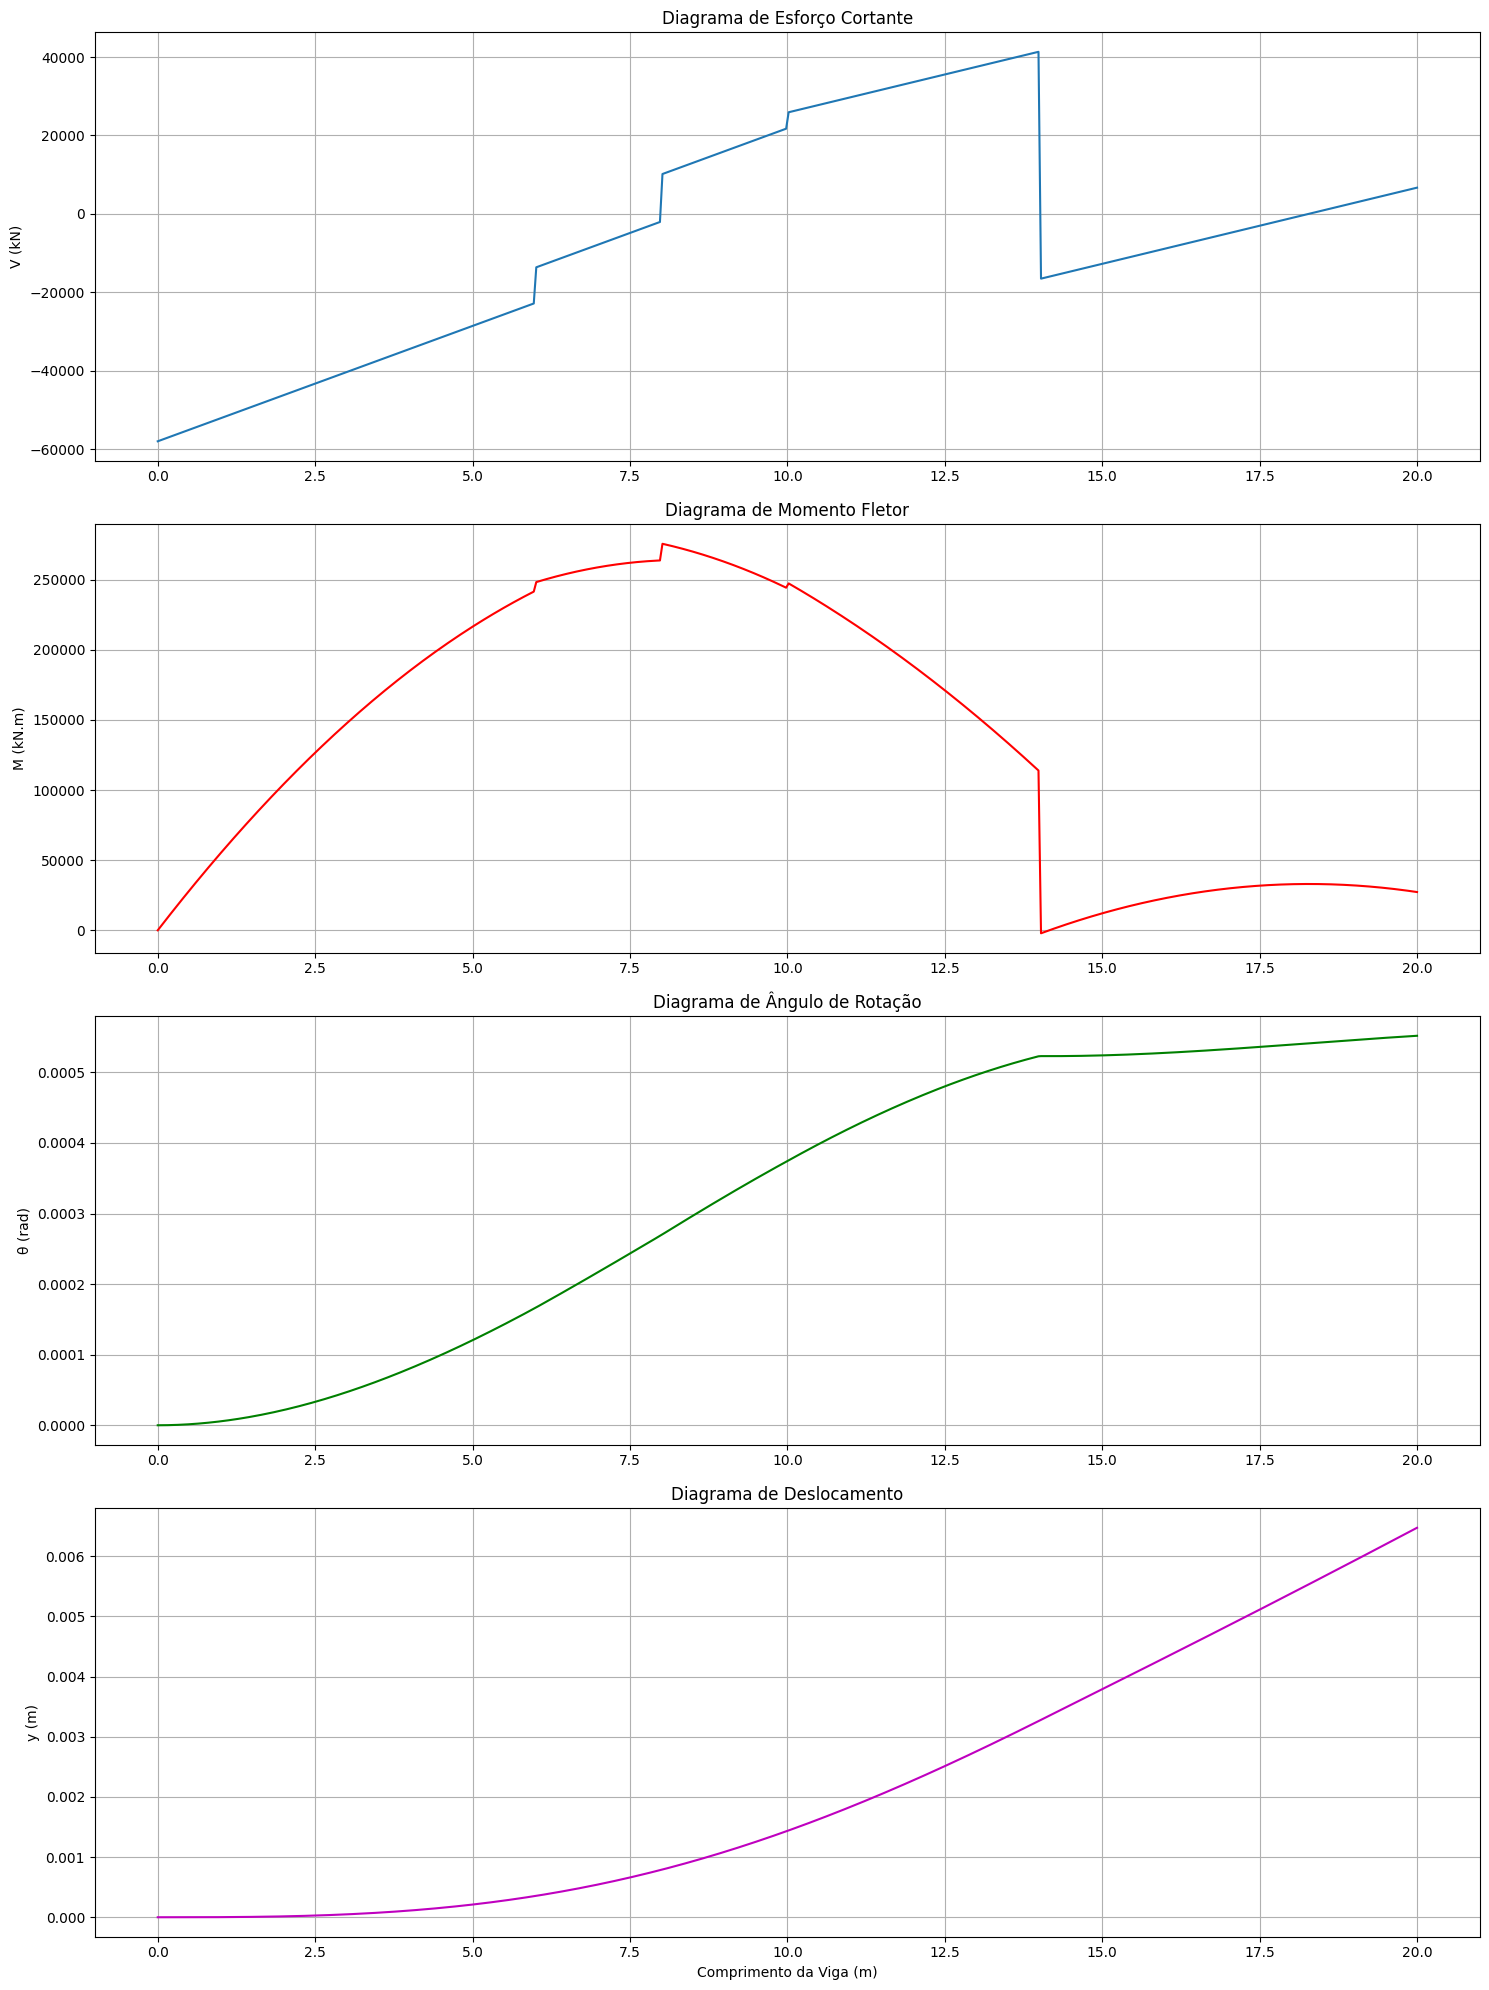

In [80]:

# Criando gráficos dos diagramas estruturais
x_vals = np.linspace(0, (L_spam1 + L_spam2), 500)
V_vals = [V.subs(x, val) for val in x_vals]
M_vals = [M.subs(x, val) for val in x_vals]
theta_vals = [theta.subs(x, val) for val in x_vals]
y_vals = [y.subs(x, val) for val in x_vals]

# Plotando os diagramas estruturais
fig, axes = plt.subplots(4, 1, figsize=(3 * 5, 4 * 5))

# Diagrama de Esforço Cortante
axes[0].plot(x_vals, V_vals, label="Esforço Cortante V(x)")
axes[0].set_ylabel("V (kN)")
axes[0].set_title("Diagrama de Esforço Cortante")
axes[0].grid(True)

# Diagrama de Momento Fletor
axes[1].plot(x_vals, M_vals, label="Momento Fletor M(x)", color='r')
axes[1].set_ylabel("M (kN.m)")
axes[1].set_title("Diagrama de Momento Fletor")
axes[1].grid(True)

# Diagrama de Ângulo de Rotação
axes[2].plot(x_vals, theta_vals, label="Ângulo de Rotação θ(x)", color='g')
axes[2].set_ylabel("θ (rad)")
axes[2].set_title("Diagrama de Ângulo de Rotação")
axes[2].grid(True)

# Diagrama de Deslocamento
axes[3].plot(x_vals, y_vals, label="Deslocamento y(x)", color='m')
axes[3].set_ylabel("y (m)")
axes[3].set_title("Diagrama de Deslocamento")
axes[3].set_xlabel("Comprimento da Viga (m)")
axes[3].grid(True)

plt.tight_layout()
plt.show()
